In [1]:
# source ~/venv/amafm/Scripts/activate
%load_ext autoreload
%autoreload 2

DATA_DIR = '../experiments'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from amafm import analysis, data_loading, denoise, evaluation, force, preprocessing, selection, visualization

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [3]:
measurements_raw, calib_params = data_loading.load_data(data_dir=DATA_DIR + '/0041_002')

Loading data from .ibw-files: 100%|██████████| 501/501 [00:29<00:00, 17.00it/s]


## Inspect data

### raw data

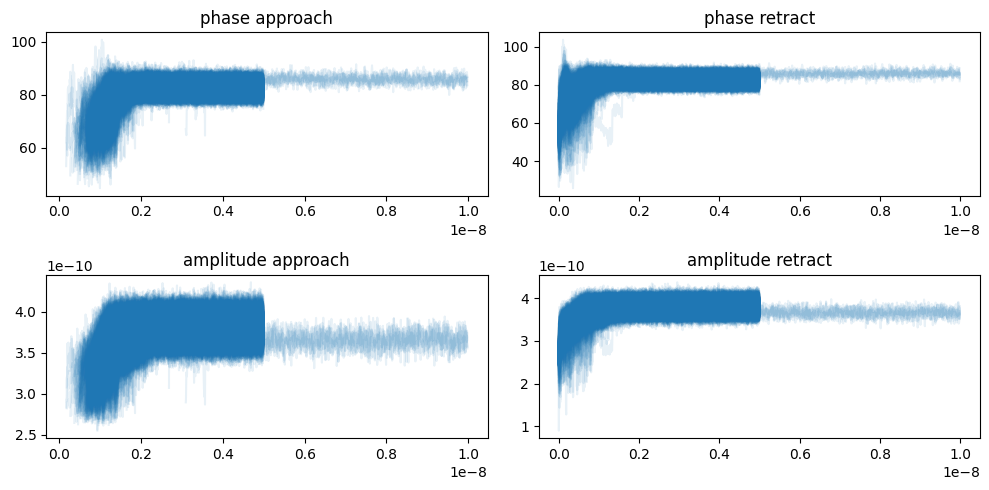

In [66]:
visualization.plot_all(measurements_raw, single_color=True, alpha=0.1, figsize=(10, 5))

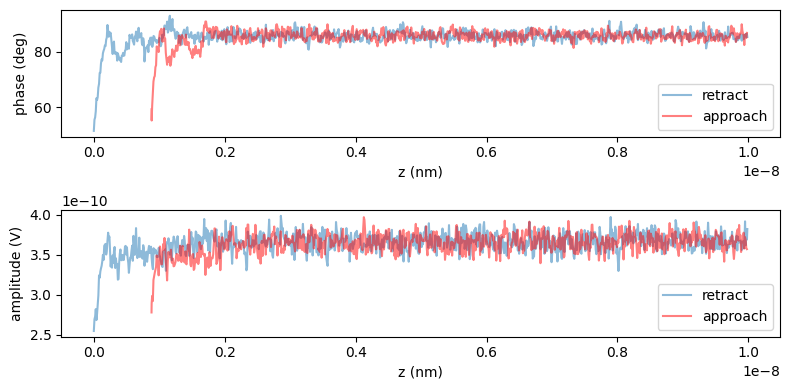

In [53]:
visualization.compare_directions(measurements_raw[5])

### preprocessed data

In [4]:
measurements, skipped_idcs = preprocessing.preprocess(measurements_raw, calib_params)

Step 1/4: Equalize lengths by interpolation:  26%|██▌       | 128/501 [00:00<00:00, 646.16it/s]

   Curves in the file 'C:\OneDrive - AIT\Studium\Master_5. Semester\Interdisciplinary Project\AM-AFM scripts\experiments\0041_002\0041_002Na_100_0233.ibw' are shorter than the desired `reduce_length=512`. Skipping file.


Step 4/4: x-alignment: 100%|██████████| 500/500 [00:00<00:00, 15625.32it/s]


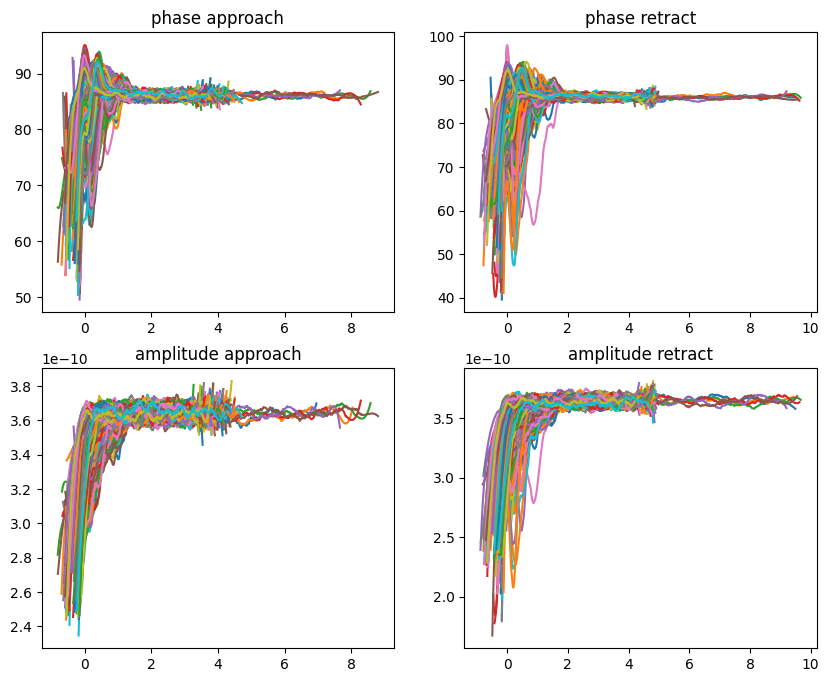

In [ ]:
visualization.plot_all(measurements, single_color=False)

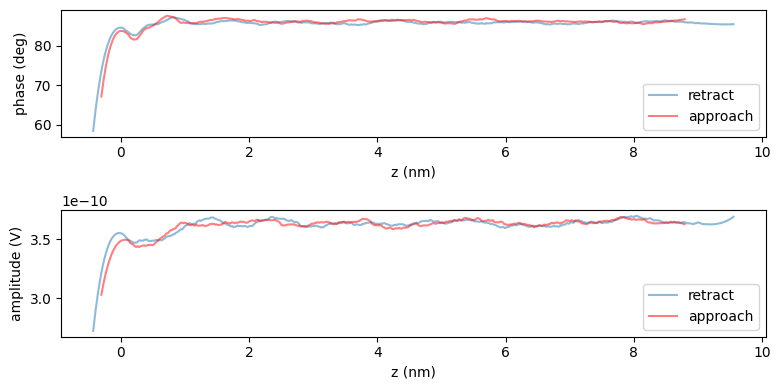

In [ ]:
visualization.compare_directions(measurements[5])

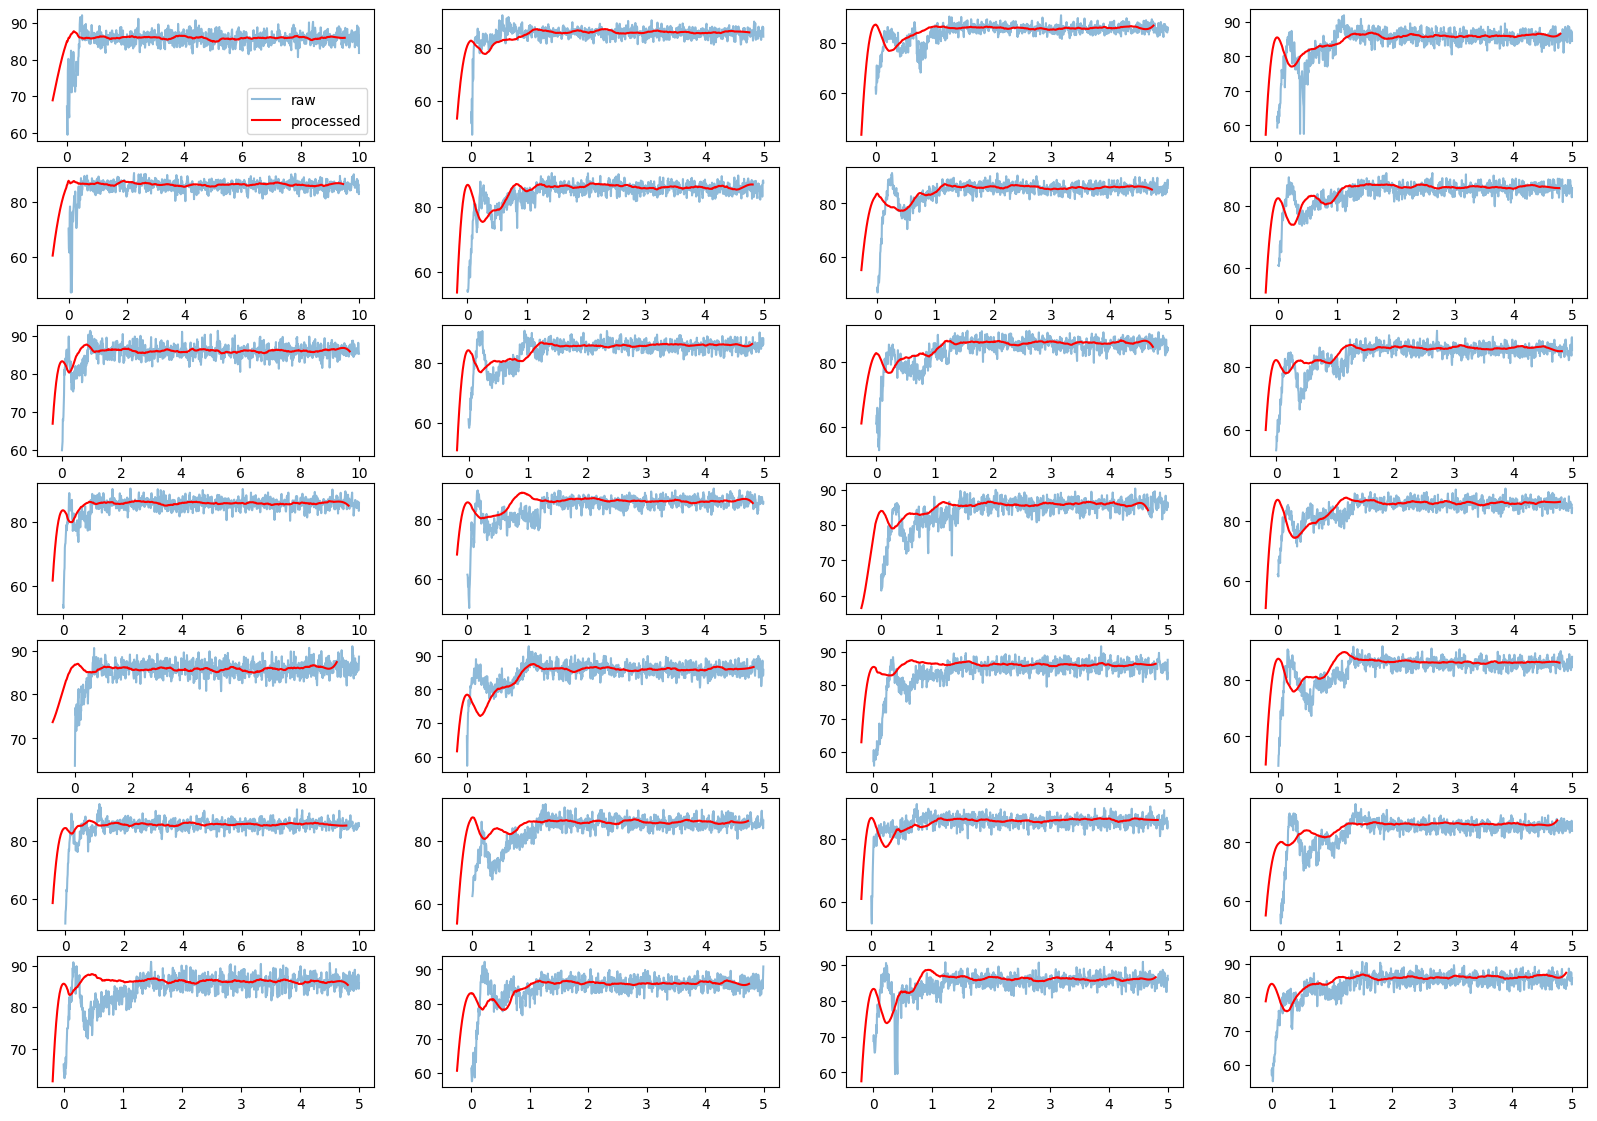

In [ ]:
visualization.compare_raw_and_processed(measurements, measurements_raw)

## Denoising

In [ ]:
smoothing_methods = [
    {'smooth_func': denoise.rolling_window, 'smooth_kwargs': {'agg': 'mean', 'w': 20, 's': 5}},
    {'smooth_func': denoise.rolling_window, 'smooth_kwargs': {'agg': 'median', 'w': 20, 's': 3}},
    {'smooth_func': denoise.rolling_window, 'smooth_kwargs': {'agg': 'median', 'w': 10, 's': 2}},
    {'smooth_func': denoise.savgol, 'smooth_kwargs': {'w': 20, 'p': 3}},
    {'smooth_func': denoise.savgol, 'smooth_kwargs': {'w': 50, 'p': 3}},
    {'smooth_func': denoise.gauss, 'smooth_kwargs': {'s': 6}},
    {'smooth_func': denoise.gauss, 'smooth_kwargs': {'s': 4}},
    {'smooth_func': denoise.gauss, 'smooth_kwargs': {'s': 2}},
    {'smooth_func': denoise.lowess, 'smooth_kwargs': {'frac': 0.01}},
    {'smooth_func': denoise.lowess, 'smooth_kwargs': {'frac': 0.015}},
    {'smooth_func': denoise.lowess, 'smooth_kwargs': {'frac': 0.02}},
    {'smooth_func': denoise.fft, 'smooth_kwargs': {'threshold': 0.06}},
    {'smooth_func': denoise.fft, 'smooth_kwargs': {'threshold': 0.05}},
]

measurements, skipped_idcs = preprocessing.preprocess(measurements_raw, calib_params, smooth=False, yalign=None, xalign=None)
results = evaluation.evaluate_smoothing(measurements, smoothing_methods, all=False)
results

Step 1/1: Equalize lengths by interpolation:  27%|██▋       | 137/501 [00:00<00:00, 677.88it/s]

   Curves in the file 'C:\OneDrive - AIT\Studium\Master_5. Semester\Interdisciplinary Project\AM-AFM scripts\experiments\0041_002\0041_002Na_100_0233.ibw' are shorter than the desired `reduce_length=512`. Skipping file.


Step 1/1: Equalize lengths by interpolation: 100%|██████████| 501/501 [00:00<00:00, 667.13it/s]


,r2,snr,ccorr,rmse
lowess {'frac': 0.01},8.349560e-01,1.106721e+00,9.131492e-01,7.584147e-12
lowess {'frac': 0.015},7.986871e-01,1.144594e+00,8.927595e-01,8.390777e-12
gauss {'s': 2},7.905100e-01,1.174544e+00,8.882829e-01,8.566050e-12
lowess {'frac': 0.02},7.606590e-01,1.179196e+00,8.706888e-01,9.171522e-12
"savgol {'w': 20, 'p': 3}",7.421021e-01,1.179673e+00,8.589865e-01,9.534512e-12
gauss {'s': 4},7.395272e-01,1.219104e+00,8.578849e-01,9.569311e-12
gauss {'s': 6},7.151750e-01,1.249958e+00,8.430894e-01,1.001955e-11
"savgol {'w': 50, 'p': 3}",7.083233e-01,1.217337e+00,8.381983e-01,1.016862e-11
"rolling_window {'agg': 'median', 'w': 10, 's': 2}",6.609624e-01,1.193510e+00,8.102684e-01,1.097479e-11
"rolling_window {'agg': 'mean', 'w': 20, 's': 5}",6.073694e-01,1.223603e+00,7.770158e-01,1.189273e-11


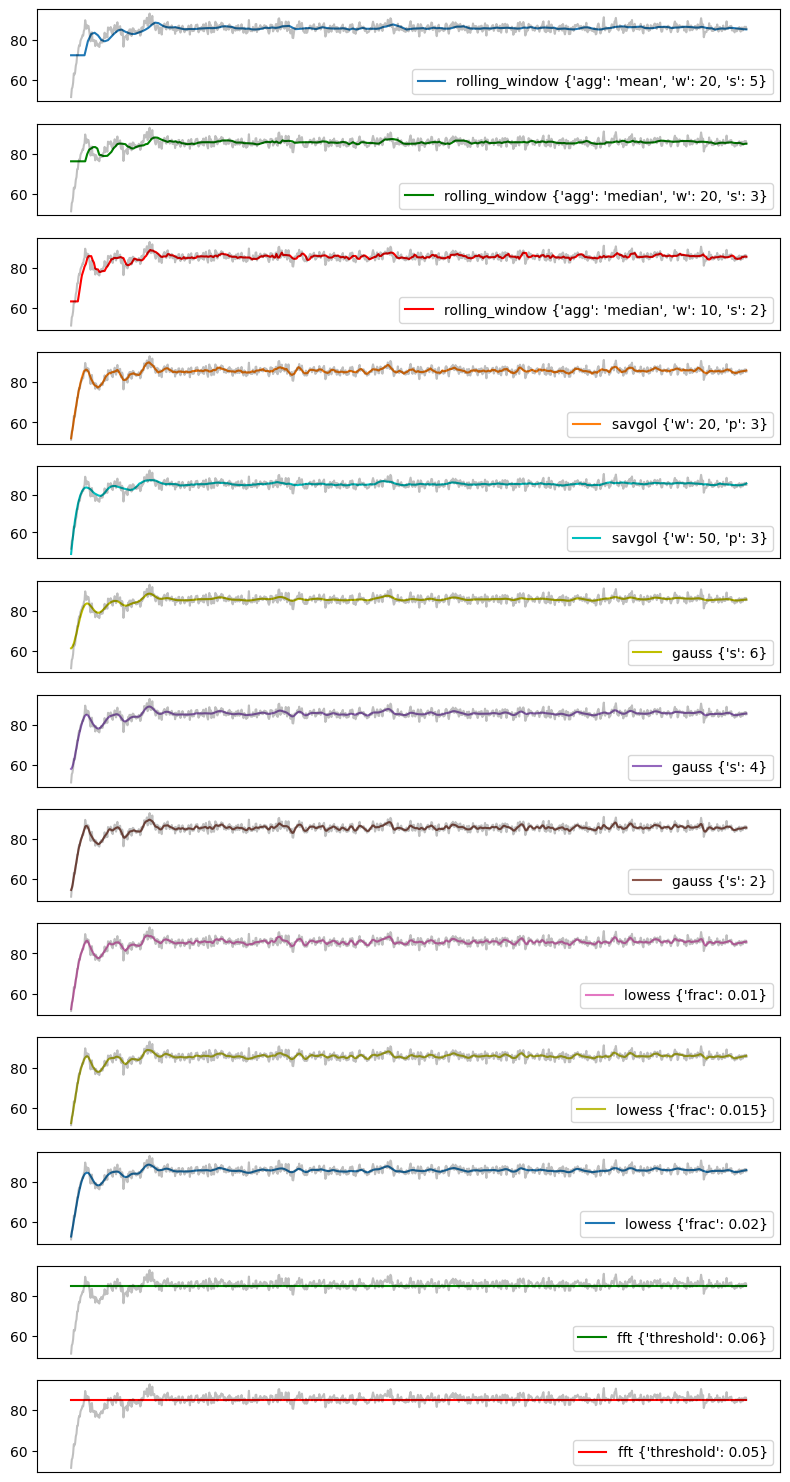

In [ ]:
i = 5
visualization.compare_smoothing(measurements_raw[i], smoothing_methods)

## y-alignment

Step 1/2: Equalize lengths by interpolation:  27%|██▋       | 133/501 [00:00<00:00, 660.44it/s]

   Curves in the file 'C:\OneDrive - AIT\Studium\Master_5. Semester\Interdisciplinary Project\AM-AFM scripts\experiments\0041_002\0041_002Na_100_0233.ibw' are shorter than the desired `reduce_length=512`. Skipping file.


Step 2/2: Denoising: 100%|██████████| 500/500 [00:00<00:00, 5539.71it/s]


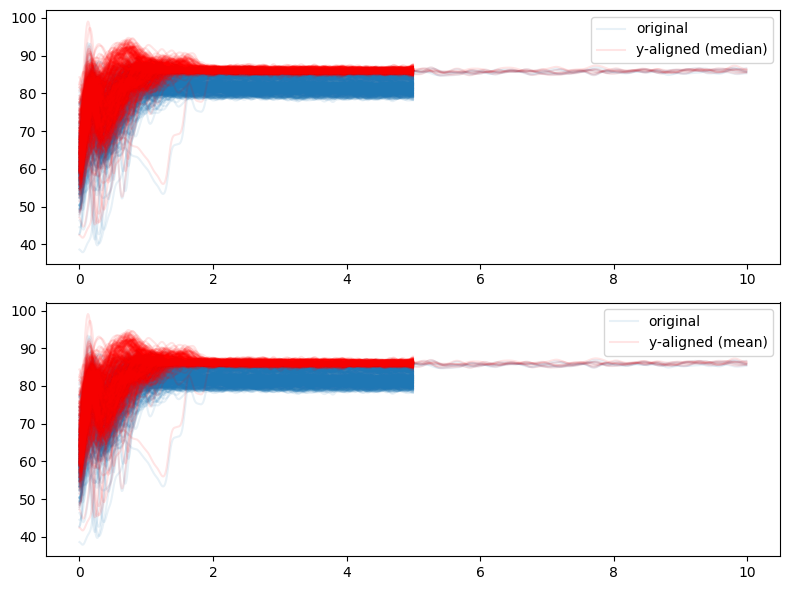

In [ ]:
measurements, skipped_idcs = preprocessing.preprocess(measurements_raw, calib_params, smooth=True, smooth_func=denoise.gauss, 
                                                      smooth_kwargs={'s': 4}, yalign=None, xalign=None)
visualization.plot_compare_yalign(measurements, calib_params, signal_type='phase', direction='out', alpha=0.1)

## x-alignment

In [67]:
measurements, skipped_idcs = preprocessing.preprocess(measurements_raw, calib_params, xalign=None)

Step 1/3: Equalize lengths by interpolation:  27%|██▋       | 135/501 [00:00<00:00, 670.70it/s]

   Curves in the file 'C:\OneDrive - AIT\Studium\Master_5. Semester\Interdisciplinary Project\AM-AFM scripts\experiments\0041_002\0041_002Na_100_0233.ibw' are shorter than the desired `reduce_length=512`. Skipping file.


Step 3/3: y-alignment: 100%|██████████| 500/500 [00:00<00:00, 5945.84it/s]


### feature extraction method

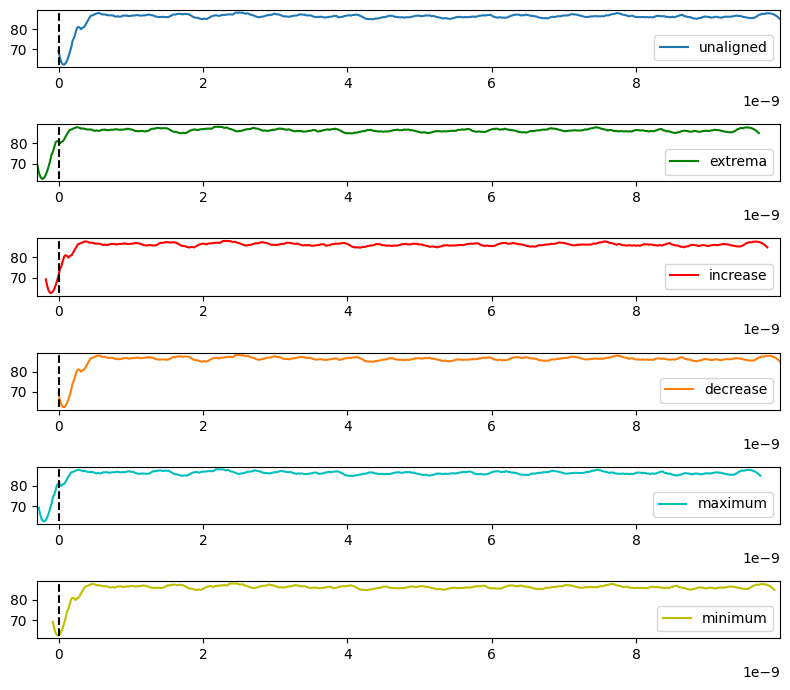

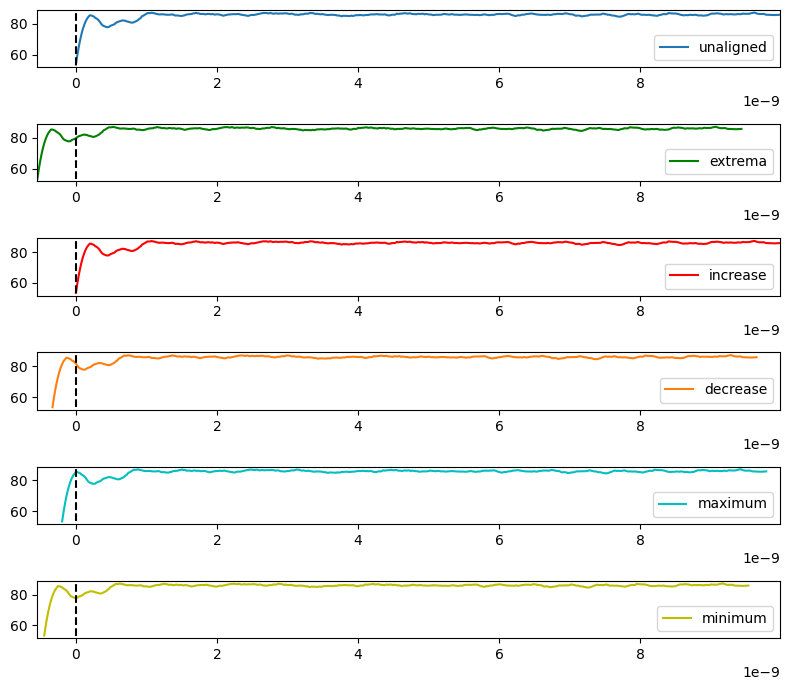

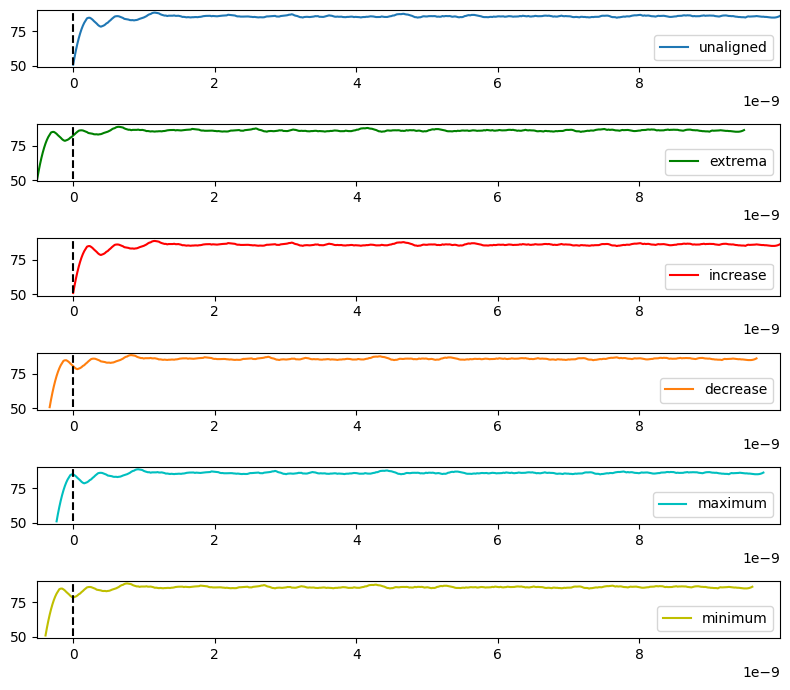

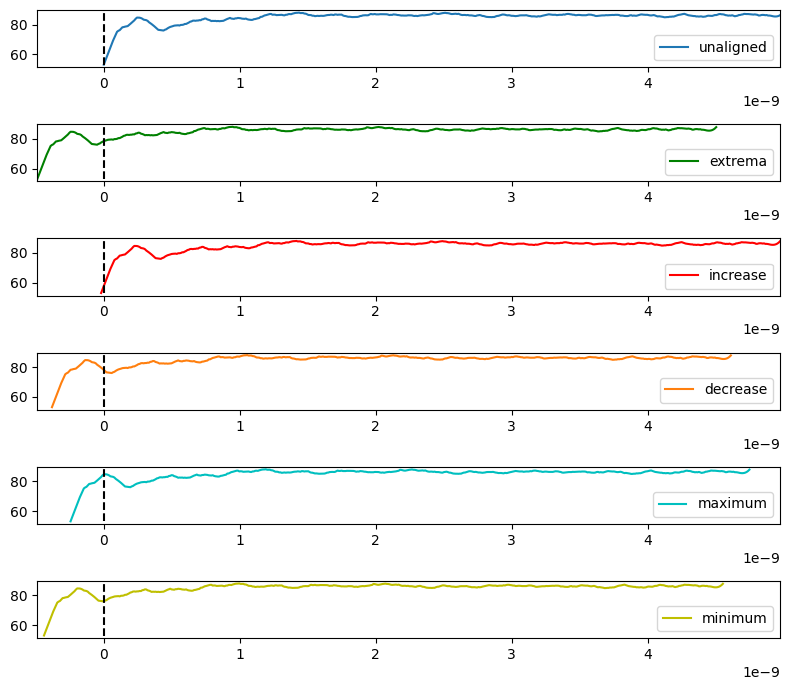

In [69]:
visualization.plot_compare_feature_xalign(measurements[1:8:2])

### dtw method

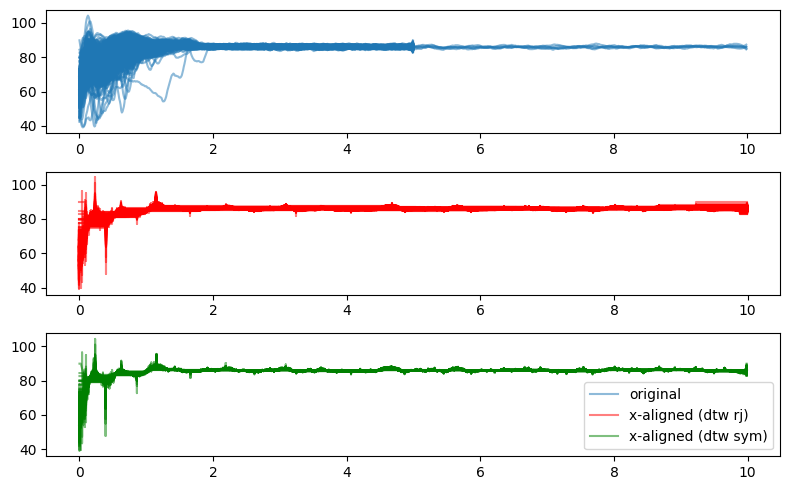

In [ ]:
visualization.plot_compare_dtw_xalign(measurements, 5)

## Identify good curves

### Manual selection

In [ ]:
# select good curves manually
!python select_experiments.py

In [ ]:
# load selected curves
measurements, calib_params = selection.load_accepted_data(DATA_DIR + '/0041_002')

In [ ]:
# load files and preprocess curves
ideal = [10, 23, 32, 67, 117, 326, 405, 410, 450, 462, 463, 483, 515]
ideal = 410
measurements, skipped_idcs = preprocessing.preprocess(measurements_raw, calib_params)

In [ ]:
# create 'screened_files.csv' from slected files
import pandas as pd
from pathlib import Path

files = data_loading.get_ibw_paths(DATA_DIR + '/0044_005')
files_acc = data_loading.get_ibw_paths(DATA_DIR + '/0044_005/PhaseSelected_0044_005')
acc_nums = [int(f.stem.split('_')[-1]) for f in files_acc]
acc_first, acc_last = min(acc_nums), max(acc_nums)

screened_files = [f for f in files if int(f.stem.split('_')[-1]) in range(acc_first, acc_last + 1)]
ndf = pd.DataFrame(columns=['filepath', 'accept'])
ndf['filepath'] = screened_files

s_filenums = pd.Series([int(f.stem.split('_')[-1]) for f in screened_files])
ndf['accept'] = s_filenums.isin(acc_nums)
ndf.to_csv(Path(DATA_DIR).resolve() / '0044_005' / selection.SAVE_NAME, index=False)
ndf

(640, 833)

### Label curves by minimal distance from pre-selection

In [ ]:
dist_classification1 = evaluation.ClassificationByDistance(DATA_DIR, ['0041_002'], test_size=0.25)
dist_classification2 = evaluation.ClassificationByDistance(DATA_DIR, ['0044_005'], test_size=0.25)

Step 4/4: x-alignment: 100%|██████████| 194/194 [00:00<00:00, 14909.12it/s]


Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 29.85it/s]


min norm:
acc   0.61
prec  0.57
rec   0.57
f1    0.57


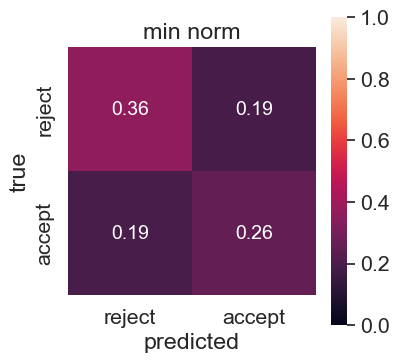

[[0.36206897 0.18965517]
 [0.19310345 0.25517241]]


Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 20.97it/s]


min norm:
acc   0.66
prec  0.56
rec   0.45
f1    0.49


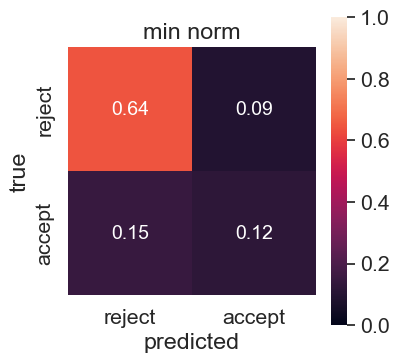

[[0.64285714 0.09183673]
 [0.14693878 0.11836735]]


In [ ]:
dist_classification1.by_min_norm(k=20)
dist_classification2.by_min_norm(k=20)

Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 31.15it/s]


min squared error:
acc   0.61
prec  0.57
rec   0.57
f1    0.57


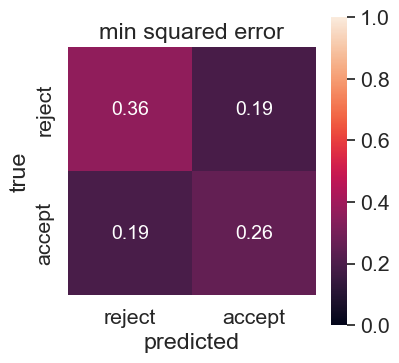

[[0.36206897 0.18965517]
 [0.19310345 0.25517241]]


Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 20.40it/s]


min squared error:
acc   0.66
prec  0.56
rec   0.45
f1    0.49


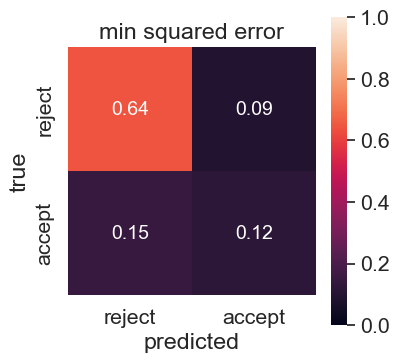

[[0.64285714 0.09183673]
 [0.14693878 0.11836735]]


In [ ]:
dist_classification1.by_min_squared(k=20)
dist_classification2.by_min_squared(k=20)

Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 32.00it/s]


min absolute error:
acc   0.63
prec  0.61
rec   0.56
f1    0.58


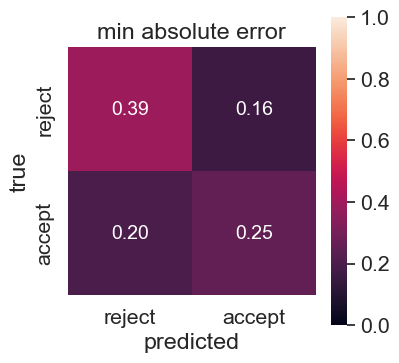

[[0.38793103 0.1637931 ]
 [0.19655172 0.25172414]]


Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 20.43it/s]


min absolute error:
acc   0.65
prec  0.56
rec   0.42
f1    0.48


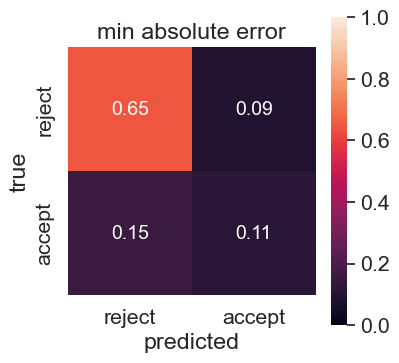

[[0.64591837 0.08877551]
 [0.15306122 0.1122449 ]]


In [ ]:
dist_classification1.by_min_abs(k=20)
dist_classification2.by_min_abs(k=20)

Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 27.32it/s]


min maxium error:
acc   0.60
prec  0.51
rec   1.00
f1    0.67


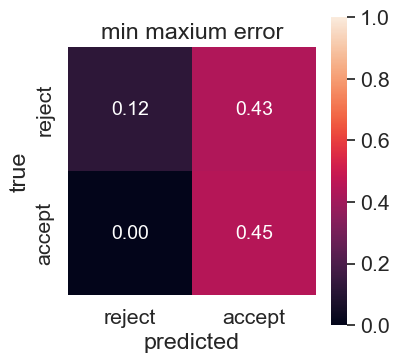

[[0.11724138 0.43448276]
 [0.00172414 0.44655172]]


Validation cycle: 100%|██████████| 20/20 [00:01<00:00, 18.30it/s]


min maxium error:
acc   0.66
prec  0.39
rec   0.78
f1    0.52


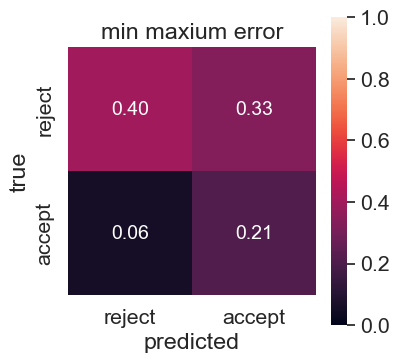

[[0.40204082 0.33265306]
 [0.05816327 0.20714286]]


In [ ]:
dist_classification1.by_min_max(k=20)
dist_classification2.by_min_max(k=20)

Validation cycle: 100%|██████████| 20/20 [00:00<00:00, 25.20it/s]


correlation:
acc   0.58
prec  0.50
rec   0.97
f1    0.66


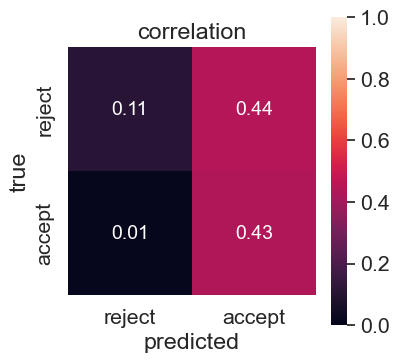

[[0.10862069 0.44310345]
 [0.0137931  0.43448276]]


Validation cycle: 100%|██████████| 20/20 [00:01<00:00, 16.34it/s]


correlation:
acc   0.70
prec  0.45
rec   0.73
f1    0.55


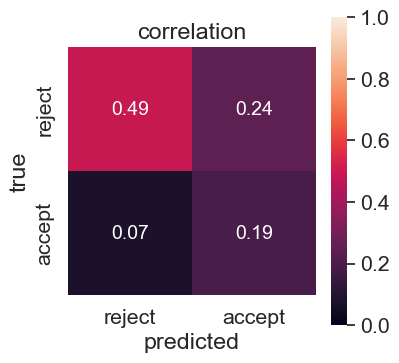

[[0.48979592 0.24489796]
 [0.07040816 0.19489796]]


In [ ]:
dist_classification1.by_correlation(k=20)
dist_classification2.by_correlation(k=20)

Validation cycle: 100%|██████████| 10/10 [05:26<00:00, 32.66s/it]


dtw:
acc   0.64
prec  0.59
rec   0.62
f1    0.60


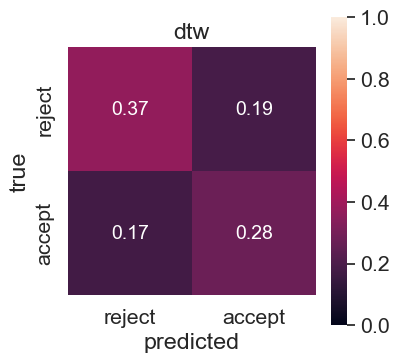

[[0.36551724 0.1862069 ]
 [0.17241379 0.27586207]]


Validation cycle: 100%|██████████| 10/10 [15:49<00:00, 94.93s/it]

dtw:
acc   0.66
prec  0.63
rec   0.42
f1    0.50


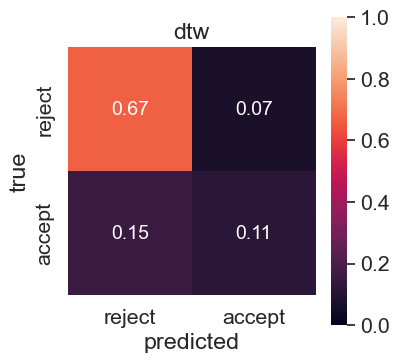

[[0.66530612 0.06938776]
 [0.15306122 0.1122449 ]]


In [ ]:
dist_classification1.by_dtw(k=10)
dist_classification2.by_dtw(k=10)

In [ ]:
dist_classification1.by_procrustes(k=1)
dist_classification2.by_procrustes(k=1)

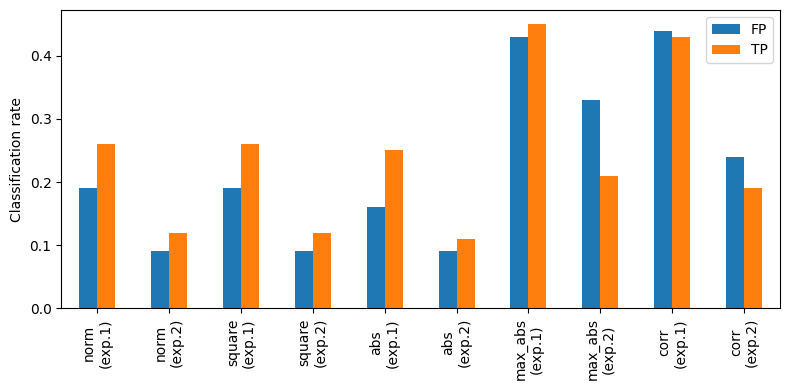

,FP,TP
name,,
norm\n(exp.1),0.19,0.26
norm\n(exp.2),0.09,0.12
square\n(exp.1),0.19,0.26
square\n(exp.2),0.09,0.12
abs\n(exp.1),0.16,0.25
abs\n(exp.2),0.09,0.11
max_abs\n(exp.1),0.43,0.45
max_abs\n(exp.2),0.33,0.21
corr\n(exp.1),0.44,0.43


In [107]:
import pandas as pd

results = [
    ('norm', '0041_002', 0.19, 0.26),
    ('norm', '0044_005', 0.09, 0.12),
    ('square', '0041_002', 0.19, 0.26),
    ('square', '0044_005', 0.09, 0.12),
    ('abs', '0041_002', 0.16, 0.25),
    ('abs', '0044_005', 0.09, 0.11),
    ('max_abs', '0041_002', 0.43, 0.45),
    ('max_abs', '0044_005', 0.33, 0.21),
    ('corr', '0041_002', 0.44, 0.43),
    ('corr', '0044_005', 0.24, 0.19),
    # ('dtw', '0041_002', 0.19, 0.28),
    # ('dtw', '0044_005', 0.07, 0.11),
]

n1 = 112
n2 = 194
results = pd.DataFrame(results, columns=['method', 'experiment', 'FP', 'TP'])
results['experiment'] = results['experiment'].str.replace('0041_002', 'exp.1')
results['experiment'] = results['experiment'].str.replace('0044_005', 'exp.2')
results['name'] = results['method'] + '\n(' + results['experiment'] + ')'
results = results.set_index('name')
results = results.drop(columns=['method', 'experiment'])
# results = results.groupby('method').agg({'FP': 'mean', 'TP': 'mean'})

fig, ax = plt.subplots(figsize=(8, 4))
results.plot(kind='bar', ax=ax, rot=90)
plt.ylabel('Classification rate')
plt.xlabel(None)
plt.tight_layout()
plt.show()

results

### ML model

In [3]:
from amafm import ml

MODEL_DIR = 'models'
folders = ['0041_002', '0044_005']
seed = 22

# neural network settings
save_dir = 'saves'
val_size = 0.2
epochs = 500
batch_size = 64
num_workers = 4

df, mct = ml.load_dataset(DATA_DIR, folders)

Loading data from .ibw-files: 100%|██████████| 194/194 [00:11<00:00, 17.13it/s]


#### SVM

In [478]:
models = [ml.MODELS['SVM']]
best_model, results, conf_mats = ml.train_curve_selection_models('SVM', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, 
                                                                 test_size=0.1, cutoff=100, scale=True, inverse_scale=False)

Validation cycle: 100%|██████████| 5/5 [00:00<00:00, 51.99it/s]


('SVM_0', 0):{'acc': np.float64(0.6523809523809524), 'prec': 0.6666666666666666, 'rec': 0.4, 'f1': 0.5}
('SVM_0', 1):{'acc': np.float64(0.6023809523809524), 'prec': 0.6, 'rec': 0.3, 'f1': 0.4}
('SVM_0', 2):{'acc': np.float64(0.6833333333333333), 'prec': 0.5, 'rec': 0.7, 'f1': 0.5833333333333334}
('SVM_0', 3):{'acc': np.float64(0.6761904761904762), 'prec': 0.8, 'rec': 0.4, 'f1': 0.5333333333333333}
('SVM_0', 4):{'acc': np.float64(0.6785714285714286), 'prec': 0.625, 'rec': 0.5, 'f1': 0.5555555555555556}


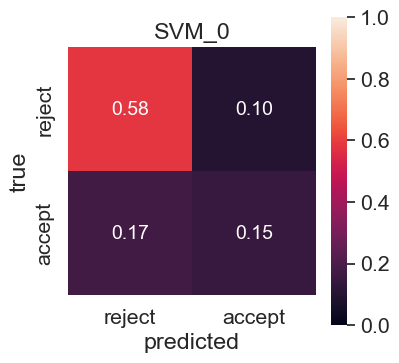

[[0.58064516 0.09677419]
 [0.17419355 0.1483871 ]]


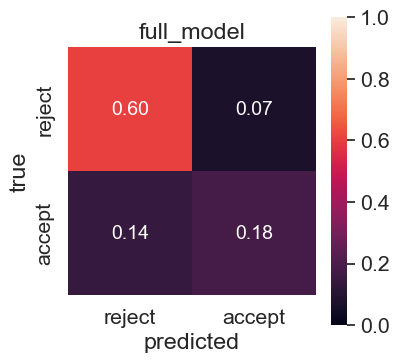

[[0.60130719 0.07189542]
 [0.14379085 0.18300654]]


,acc,prec,rec,f1
SVM_0,0.658571,0.638333,0.46,0.514444
full_model,0.726602,0.717949,0.56,0.629213


In [479]:
ml.print_results(results, conf_mats)

#### RandomForest

In [472]:
models = [ml.MODELS['RF']]
best_model, results, conf_mats = ml.train_curve_selection_models('RF', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, 
                                                                 test_size=0.1, cutoff=100)

Validation cycle:  60%|██████    | 3/5 [00:00<00:00, 10.43it/s]

('RF_0', 0):{'acc': np.float64(0.6023809523809524), 'prec': 0.6, 'rec': 0.3, 'f1': 0.4}
('RF_0', 1):{'acc': np.float64(0.5761904761904761), 'prec': 0.6666666666666666, 'rec': 0.2, 'f1': 0.3076923076923077}
('RF_0', 2):{'acc': np.float64(0.7023809523809523), 'prec': 0.7142857142857143, 'rec': 0.5, 'f1': 0.5882352941176471}


Validation cycle: 100%|██████████| 5/5 [00:00<00:00, 10.35it/s]

('RF_0', 3):{'acc': np.float64(0.6261904761904762), 'prec': 0.75, 'rec': 0.3, 'f1': 0.42857142857142855}
('RF_0', 4):{'acc': np.float64(0.7023809523809523), 'prec': 0.7142857142857143, 'rec': 0.5, 'f1': 0.5882352941176471}


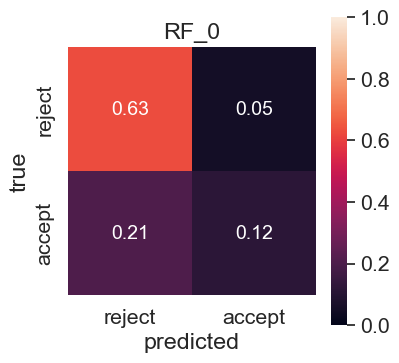

[[0.62580645 0.0516129 ]
 [0.20645161 0.11612903]]


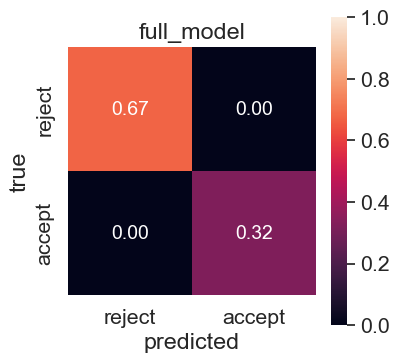

[[0.67320261 0.        ]
 [0.00326797 0.32352941]]


,acc,prec,rec,f1
RF_0,0.641905,0.689048,0.36,0.462547
full_model,0.995000,1.000000,0.99,0.994975


In [473]:
ml.print_results(results, conf_mats)

#### GradientBoosting

In [4]:
models = [ml.MODELS['GB']]
best_model, results, conf_mats = ml.train_curve_selection_models('GB', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, 
                                                                 test_size=0.1, cutoff=100)

Validation cycle:  20%|██        | 1/5 [00:00<00:01,  2.12it/s]

('GB_0', 0):{'acc': np.float64(0.6047619047619048), 'prec': 0.5, 'rec': 0.4, 'f1': 0.4444444444444444}


Validation cycle:  40%|████      | 2/5 [00:00<00:01,  2.19it/s]

('GB_0', 1):{'acc': np.float64(0.6285714285714286), 'prec': 0.5714285714285714, 'rec': 0.4, 'f1': 0.47058823529411764}


Validation cycle:  60%|██████    | 3/5 [00:01<00:00,  2.11it/s]

('GB_0', 2):{'acc': np.float64(0.5809523809523809), 'prec': 0.4444444444444444, 'rec': 0.4, 'f1': 0.42105263157894735}


Validation cycle:  80%|████████  | 4/5 [00:01<00:00,  2.09it/s]

('GB_0', 3):{'acc': np.float64(0.6785714285714286), 'prec': 0.625, 'rec': 0.5, 'f1': 0.5555555555555556}


Validation cycle: 100%|██████████| 5/5 [00:02<00:00,  2.08it/s]

('GB_0', 4):{'acc': np.float64(0.7785714285714285), 'prec': 0.7, 'rec': 0.7, 'f1': 0.7}


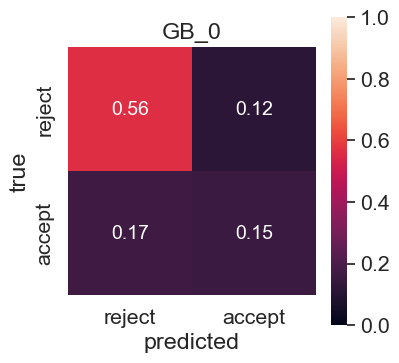

[[0.56129032 0.11612903]
 [0.16774194 0.15483871]]


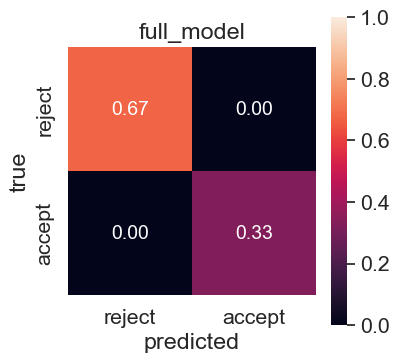

[[0.67320261 0.        ]
 [0.         0.32679739]]


,acc,prec,rec,f1
GB_0,0.654286,0.568175,0.48,0.518328
full_model,1.000000,1.000000,1.00,1.000000


In [5]:
ml.print_results(results, conf_mats)

#### CRF

In [11]:
models = [ml.MODELS['CRF']]
best_model, results, conf_mats = ml.train_curve_selection_models('CRF', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, test_size=0.1,
                                                                 cutoff=100)

Validation cycle:  20%|██        | 1/5 [00:00<00:02,  1.53it/s]

('CRF_0', 0):{'acc': np.float64(0.5), 'prec': 0.3225806451612903, 'rec': 1.0, 'f1': 0.4878048780487805}
('CRF_0', 1):{'acc': np.float64(0.5), 'prec': 0.3225806451612903, 'rec': 1.0, 'f1': 0.4878048780487805}


Validation cycle:  80%|████████  | 4/5 [00:01<00:00,  3.54it/s]

('CRF_0', 2):{'acc': np.float64(0.5), 'prec': 0.3225806451612903, 'rec': 1.0, 'f1': 0.4878048780487805}
('CRF_0', 3):{'acc': np.float64(0.5), 'prec': 0.3225806451612903, 'rec': 1.0, 'f1': 0.4878048780487805}


Validation cycle: 100%|██████████| 5/5 [00:01<00:00,  3.28it/s]


('CRF_0', 4):{'acc': np.float64(0.5), 'prec': 0.3225806451612903, 'rec': 1.0, 'f1': 0.4878048780487805}


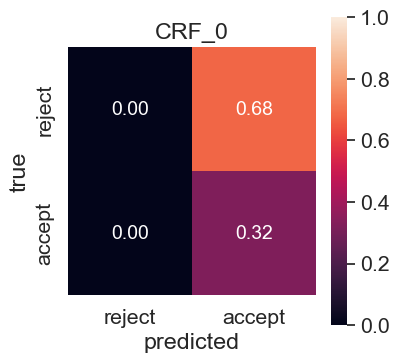

[[0.         0.67741935]
 [0.         0.32258065]]


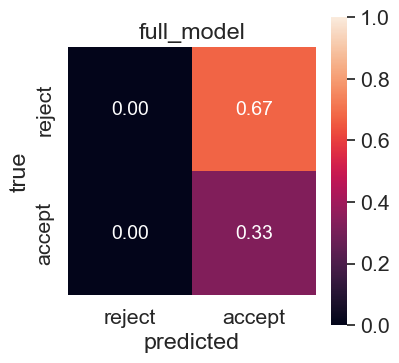

[[0.         0.67320261]
 [0.         0.32679739]]


,acc,prec,rec,f1
CRF_0,0.5,0.322581,1.0,0.487805
full_model,0.5,0.326797,1.0,0.492611


In [12]:
ml.print_results(results, conf_mats)

#### CNN
* hidden_dims=[16, 32, 64, 128, 256, 512, 1000]

In [ ]:
models = [ml.MODELS['CNN']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNN', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, test_size=0.1)

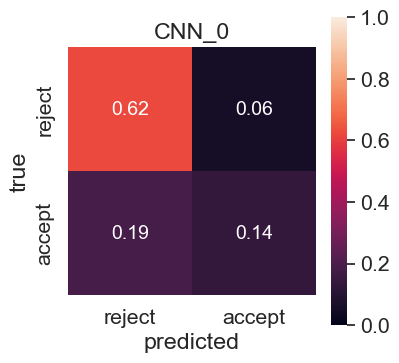

[[0.61935484 0.05806452]
 [0.18709677 0.13548387]]


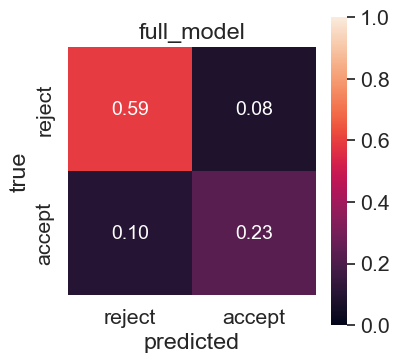

[[0.59150327 0.08169935]
 [0.09803922 0.22875817]]


,acc,prec,rec,f1
CNN_0,0.667143,0.669841,0.42,0.499819
full_model,0.789320,0.736842,0.70,0.717949


In [39]:
ml.print_results(results, conf_mats)

In [ ]:
models = [ml.MODELS['CNN']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNnorm', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, test_size=0.1,
                                                                 scale=True, inverse_scale=False)

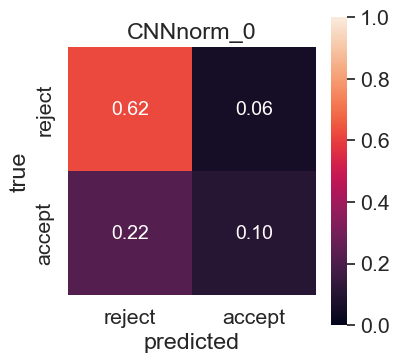

[[0.61935484 0.05806452]
 [0.21935484 0.10322581]]


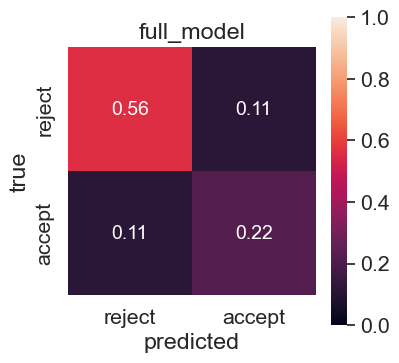

[[0.5620915  0.11111111]
 [0.11111111 0.21568627]]


,acc,prec,rec,f1
CNNnorm_0,0.617143,0.410549,0.32,0.346053
full_model,0.747476,0.660000,0.66,0.660000


In [16]:
ml.print_results(results, conf_mats)

#### CNN with cutoff curves
* hidden_dims=[16, 32, 64, 128, 256, 512, 1000], cutoff at 100

In [ ]:
models = [ml.MODELS['CNN_cutoff']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNtrim', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, test_size=0.1, 
                                                                 cutoff=100)

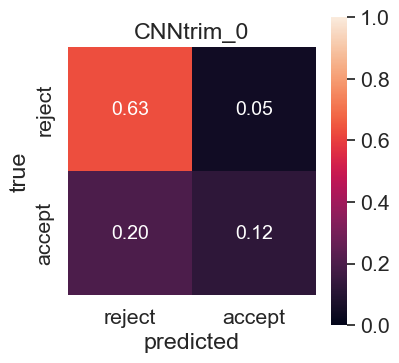

[[0.63225806 0.04516129]
 [0.2        0.12258065]]


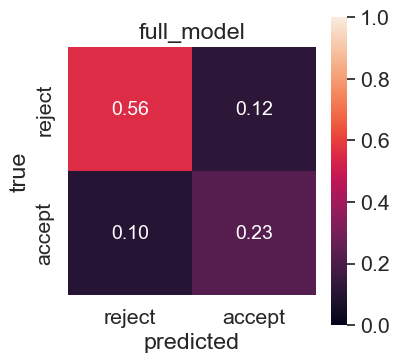

[[0.55555556 0.11764706]
 [0.10130719 0.2254902 ]]


,acc,prec,rec,f1
CNNtrim_0,0.656667,0.592857,0.38,0.458123
full_model,0.757621,0.657143,0.69,0.673171


In [18]:
ml.print_results(results, conf_mats)

In [ ]:
models = [ml.MODELS['CNN_cutoff']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNtrim_norm', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, test_size=0.1, 
                                                                 cutoff=100, scale=True, inverse_scale=False)

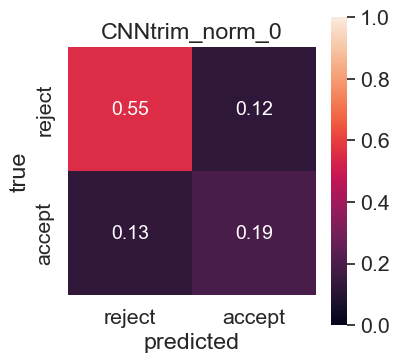

[[0.55483871 0.12258065]
 [0.12903226 0.19354839]]


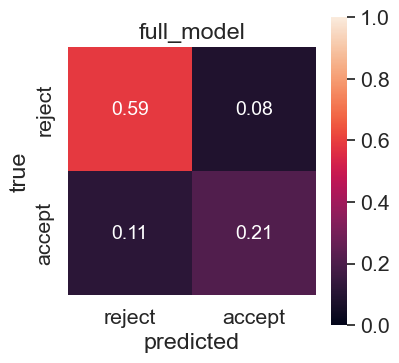

[[0.58823529 0.08496732]
 [0.11437908 0.2124183 ]]


,acc,prec,rec,f1
CNNtrim_norm_0,0.709524,0.632857,0.60,0.607647
full_model,0.761893,0.714286,0.65,0.680628


In [20]:
ml.print_results(results, conf_mats)

#### CNN with Batchnorm and Dropout
* dropout=0.5, hidden_dims=[128, 256, 1000]

In [ ]:
models = [ml.MODELS['CNN_BN_DO']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNdropout', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, test_size=0.1)

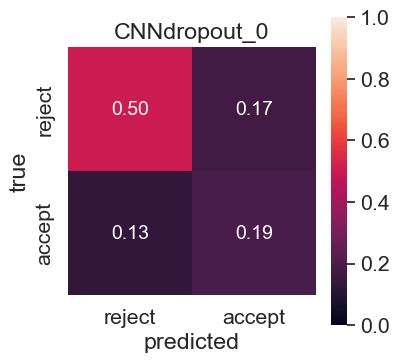

[[0.50322581 0.17419355]
 [0.12903226 0.19354839]]


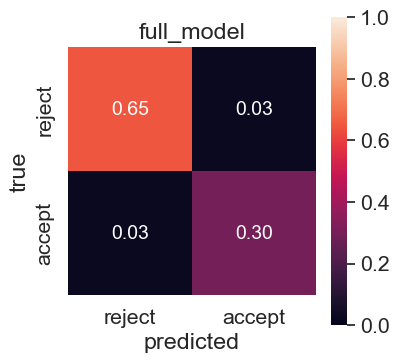

[[0.64705882 0.02614379]
 [0.02941176 0.29738562]]


,acc,prec,rec,f1
CNNdropout_0,0.671429,0.531410,0.60,0.559332
full_model,0.935583,0.919192,0.91,0.914573


In [22]:
ml.print_results(results, conf_mats)

In [ ]:
models = [ml.MODELS['CNN_BN_DO']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNdropout_norm', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, 
                                                                 test_size=0.1, scale=True, inverse_scale=False)

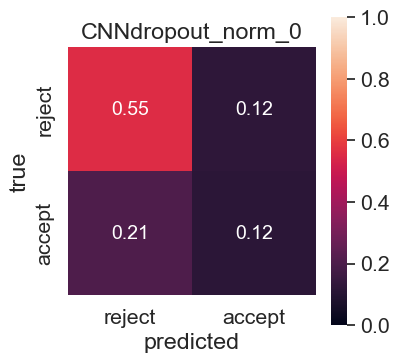

[[0.55483871 0.12258065]
 [0.20645161 0.11612903]]


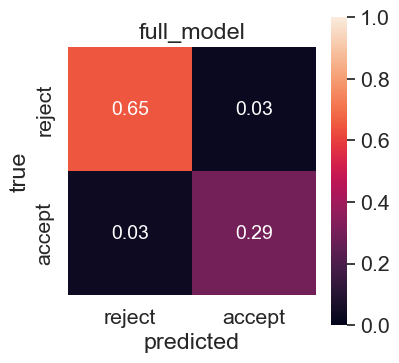

[[0.64705882 0.02614379]
 [0.03267974 0.29411765]]


,acc,prec,rec,f1
CNNdropout_norm_0,0.589524,0.488889,0.36,0.407018
full_model,0.930583,0.918367,0.90,0.909091


In [24]:
ml.print_results(results, conf_mats)

#### CNN with Batchnorm, Dropout and curve cutoff
* dropout=0.5, hidden_dims=[128, 256, 1000], cutoff at 100

In [ ]:
models = [ml.MODELS['CNN_BN_DO_cutoff']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNdropout_trim', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, 
                                                                 test_size=0.1, cutoff=100)

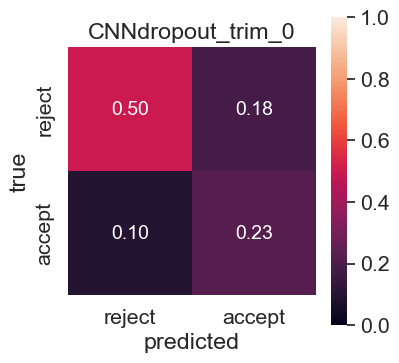

[[0.49677419 0.18064516]
 [0.09677419 0.22580645]]


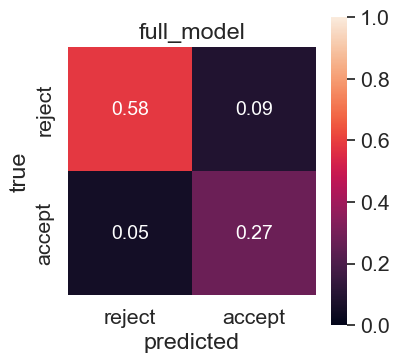

[[0.58496732 0.08823529]
 [0.05228758 0.2745098 ]]


,acc,prec,rec,f1
CNNdropout_trim_0,0.716667,0.562828,0.70,0.614115
full_model,0.854466,0.756757,0.84,0.796209


In [31]:
ml.print_results(results, conf_mats)

In [ ]:
models = [ml.MODELS['CNN_BN_DO_cutoff']]
best_model, results, conf_mats = ml.train_curve_selection_models('CNNdropout_trim_norm', df, mct, models, cross_val_k=5, model_dir=MODEL_DIR, 
                                                                 test_size=0.1, cutoff=100, scale=True, inverse_scale=False)

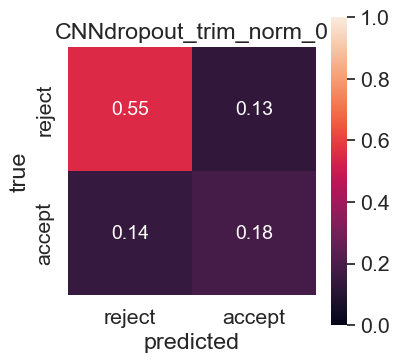

[[0.5483871  0.12903226]
 [0.14193548 0.18064516]]


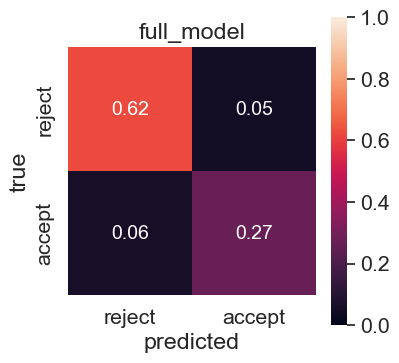

[[0.62418301 0.04901961]
 [0.05882353 0.26797386]]


,acc,prec,rec,f1
CNNdropout_trim_norm_0,0.684762,0.656190,0.56,0.573314
full_model,0.873592,0.845361,0.82,0.832487


In [26]:
ml.print_results(results, conf_mats)

#### LSTM
* not suitable with too few samples

In [ ]:
models = [ml.MODELS['LSTM_cutoff']]
best_model, results, conf_mats = ml.train_curve_selection_models('LSTMtrim_norm', df, mct, models, cross_val_k=1, model_dir=MODEL_DIR, test_size=0.1,
                                                                 cutoff=100, scale=True, inverse_scale=False)

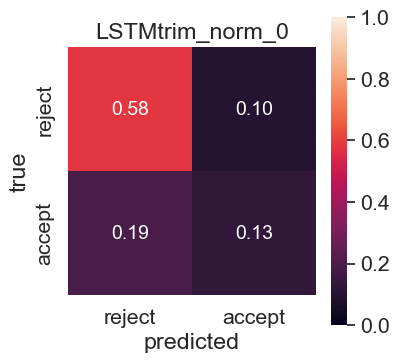

[[0.58064516 0.09677419]
 [0.19354839 0.12903226]]


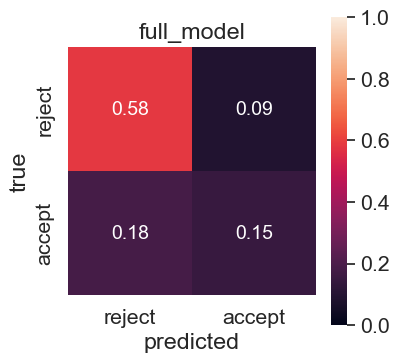

[[0.58496732 0.08823529]
 [0.17973856 0.14705882]]


,acc,prec,rec,f1
LSTMtrim_norm_0,0.628571,0.571429,0.40,0.470588
full_model,0.659466,0.625000,0.45,0.523256


In [37]:
ml.print_results(results, conf_mats)

#### ResNet CNN

In [ ]:
from amafm.ml import NeuralNetworkClassifier, ResNet

def models_provider():
    return [
        NeuralNetworkClassifier('ResNet', ResNet, save_dir=save_dir, in_channels=input_len, out_channels=1, batch_size=batch_size, 
                                val_size=val_size, num_workers=num_workers, max_epochs=epochs, lstm_size=128, n_lstm_layers=3, 
                                fc_size=1000, dropout=0.5),
    ]
models, results, conf_mats = ml.train_curve_selection_models(df, models_provider, cross_val_k=1, model_dir=MODEL_DIR, test_size=0.1, 
                                                             batch_size=16)

In [ ]:
ml.print_results(results, conf_mats)

#### RandomForest with transposed data
* each input sample is a tuple of (z-step, y-value)

Validation cycle: 100%|██████████| 1/1 [00:06<00:00,  6.58s/it]


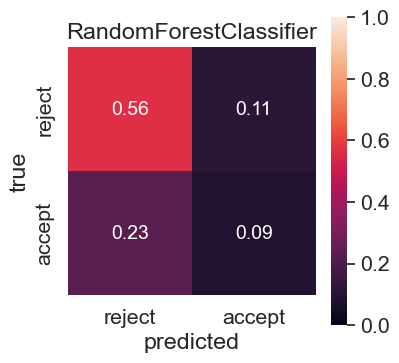

[[0.56470514 0.11271421]
 [0.23393397 0.08864667]]


,acc,prec,rec,f1
RandomForestClassifier,0.554209,0.440238,0.274805,0.338384


In [ ]:
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import ensemble, metrics, svm
from sklearn import model_selection as ms
from sklearn.base import BaseEstimator
from tqdm import trange


curve_type = 'phase_out'
cross_val_k = 1
test_size = 0.2
seed = 12


def split_data(df_accepted: pd.DataFrame, df_rejected: pd.DataFrame, test_size: float = 0.2,
                seed: int = 12) -> tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    train, test = ml.train_test_split(df_accepted, df_rejected, test_size=test_size, seed=seed)
    X_train = np.stack([np.concatenate(train['curve'].values), np.concatenate(train['z'].values)]).T
    X_test = np.stack([np.concatenate(test['curve'].values), np.concatenate(test['z'].values)]).T
    n_rep = len(train['curve'][0])
    y_train, y_test = np.repeat(train['accept'].values, n_rep), np.repeat(test['accept'].values, n_rep)
    return X_train, y_train, X_test, y_test


# load filepaths and data
df_list = []
m_list = []
for folder in folders:
    df = selection.load_screening_results(Path(DATA_DIR, folder))
    measurements, calib_params = data_loading.load_data(files=df.filepath.tolist())
    measurements, _ = preprocessing.preprocess(measurements, calib_params)

    # drop filepaths which from which data could not be loaded
    m_filepaths = [m.file_path for m in measurements]
    df = df.drop(index=df.index[~df.filepath.isin(m_filepaths)])
    
    df_list.append(df)
    m_list.extend(measurements)
df = pd.concat(df_list, ignore_index=True)
df['curve'] = [m[curve_type] for m in m_list]
df['z'] = [m.z_out for m in m_list]
df, measurements = df, m_list

# separate accept-status to balance splits
df_accepted = df[df.accept]
df_rejected = df[~df.accept]

results = {}
conf_mats = {}
for i in trange(cross_val_k, desc='Validation cycle'):
    models = [
        # svm.SVC(),
        ensemble.RandomForestClassifier(n_jobs=-1, random_state=seed),
    ]

    X_train, y_train, X_test, y_test = split_data(df_accepted, df_rejected, test_size=test_size, seed=seed + (i * 2))
    for model in models:
        model.fit(X_train, y_train)
        scores, conf_mat = ml.evaluate_model(model, X_test, y_test)
        model_name = model.__class__.__qualname__
        results[(model_name, i)] = scores

        if model_name not in conf_mats:
            conf_mats[model_name] = []
        conf_mats[model_name].append(conf_mat)
results = pd.DataFrame(results).T.groupby(level=0).mean()

labels = ['reject', 'accept']
for name, cms in conf_mats.items():
    cm = np.mean(cms, axis=0)
    visualization.plot_conf_mat(cm, labels, name)

results

#### Comparison

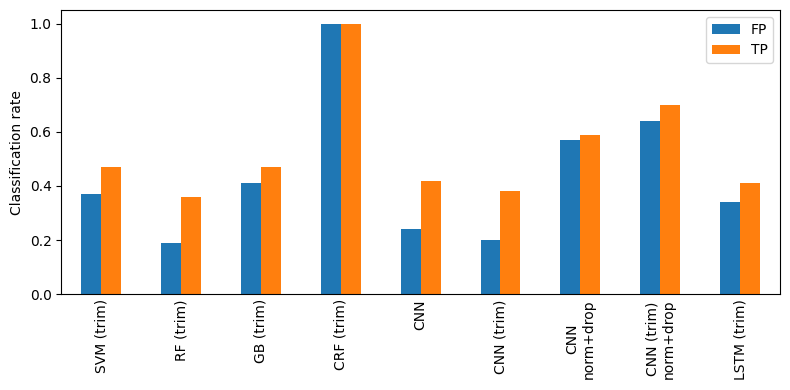

,FP,TP
model,,
SVM (trim),0.37,0.47
RF (trim),0.19,0.36
GB (trim),0.41,0.47
CRF (trim),1.00,1.00
CNN,0.24,0.42
CNN (trim),0.20,0.38
CNN\nnorm+drop,0.57,0.59
CNN (trim)\nnorm+drop,0.64,0.70
LSTM (trim),0.34,0.41


In [11]:
import pandas as pd

results = [
    ('SVM (trim)', 0.10, 0.15, 0.58, 0.17),
    ('RF (trim)', 0.05, 0.12, 0.63, 0.21),
    ('GB (trim)', 0.12, 0.15, 0.56, 0.17),
    ('CRF (trim)', 0.68, 0.32, 0.0, 0.0),
    ('CNN', 0.06, 0.14, 0.62, 0.19),
    ('CNN (trim)', 0.05, 0.12, 0.63, 0.20),
    ('CNN\nnorm+drop', 0.17, 0.19, 0.50, 0.13),
    ('CNN (trim)\nnorm+drop', 0.18, 0.23, 0.50, 0.10),
    ('LSTM (trim)', 0.10, 0.13, 0.58, 0.19),
]

results = pd.DataFrame(results, columns=['model', 'FP', 'TP', 'TN', 'FN'])
results = results.set_index('model')
results['FP'] = (results['FP'] / (results['FP'] + results['FN'])).round(2)
results['TP'] = (results['TP'] / (results['TP'] + results['FN'])).round(2)
results = results.drop(columns=['TN', 'FN'])

fig, ax = plt.subplots(figsize=(8, 4))
results.plot(kind='bar', ax=ax, rot=90)
plt.ylabel('Classification rate')
plt.xlabel(None)
plt.tick_params(axis='x', which='both', length=0)
plt.tight_layout()
plt.show()

results

## Averaging

In [ ]:
measurements, skipped_idcs = preprocessing.preprocess(DATA_DIR, num_files=100, xalign_n=1)

### binned averaging

Average curves for direction='out': 100%|██████████| 97/97 [00:00<00:00, 608.04it/s]


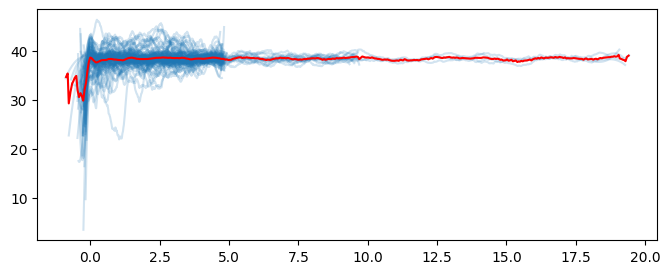

In [ ]:
avrg_measurement = analysis.average_curves(measurements, n_bins=400)
visualization.plot_averaging(avrg_measurement, measurements)

## Derive force curve

In [ ]:
measurements, calib_params_0041_002 = data_loading.load_data(data_dir=DATA_DIR + '/0041_002')
measurements_0041_002, _ = preprocessing.preprocess(measurements, calib_params_0041_002)

measurements, calib_params_0044_005 = data_loading.load_data(data_dir=DATA_DIR + '/0044_005')
measurements_0044_005, _ = preprocessing.preprocess(measurements, calib_params_0044_005)

files = selection.load_accepted_filepaths(DATA_DIR + '/0041_002')
measurements, calib_params_0041_002_good = data_loading.load_data(files=files)
measurements_0041_002_good, _ = preprocessing.preprocess(measurements, calib_params_0041_002_good)

files = selection.load_accepted_filepaths(DATA_DIR + '/0044_005')
measurements, calib_params_0044_005_good = data_loading.load_data(files=files)
measurements_0044_005_good, _ = preprocessing.preprocess(measurements, calib_params_0044_005_good)

Step 1/4: Equalize lengths by interpolation:  28%|██▊       | 138/501 [00:00<00:00, 688.42it/s]

   Curves in the file '..\experiments\0041_002\0041_002Na_100_0233.ibw' are shorter than the desired `reduce_length=512`. Skipping file.


Step 4/4: x-alignment: 100%|██████████| 50/50 [00:00<00:00, 12495.69it/s]


### Resulting force per experiment

Average curves for direction='out': 100%|██████████| 500/500 [00:00<00:00, 582.83it/s]


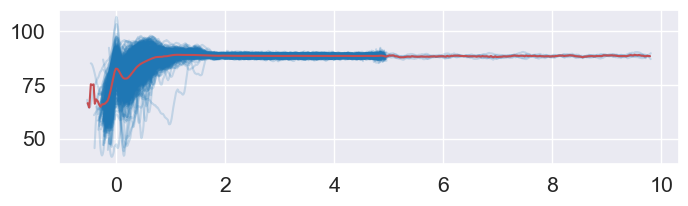

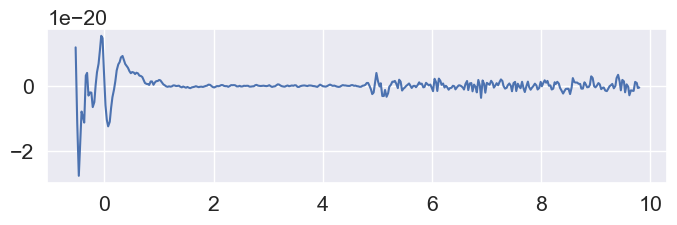

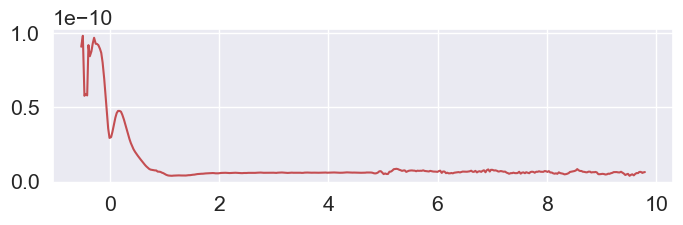

In [ ]:
avrg_measurement_0041_002 = analysis.average_curves(measurements_0041_002)
visualization.plot_averaging(avrg_measurement_0041_002, measurements_0041_002, figsize=(8, 2))

force_0041_002 = force.force_hoelscher(avrg_measurement_0041_002, calib_params_0041_002)
plt.figure(figsize=(8, 2))
plt.plot(*force_0041_002)
plt.show()

force_p_0041_002 = force.force_payman(avrg_measurement_0041_002, calib_params_0041_002_good)
plt.figure(figsize=(8, 2))
plt.plot(*force_p_0041_002, 'r')
plt.show()

In [ ]:
len(force_0041_002[1]), len(force_p_0041_002[1])

(400, 400)

In [ ]:
f1, f2 = force_0041_002[1], force_p_0041_002[1]
fmin, fmax = min([f1.min(), f2.min()]), max([f1.max(), f2.max()])
f = (f1 - fmin) / (fmax - fmin) - (f2 - fmin) / (fmax - fmin)
float(np.mean(np.abs(f[:100])))

0.2686584150191382

Average curves for direction='out': 100%|██████████| 50/50 [00:00<00:00, 581.36it/s]


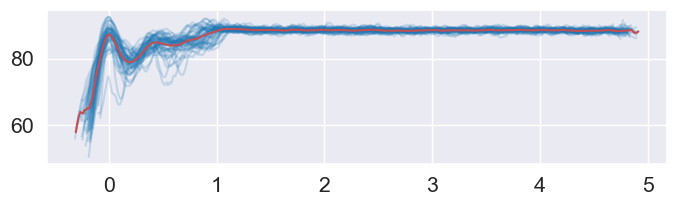

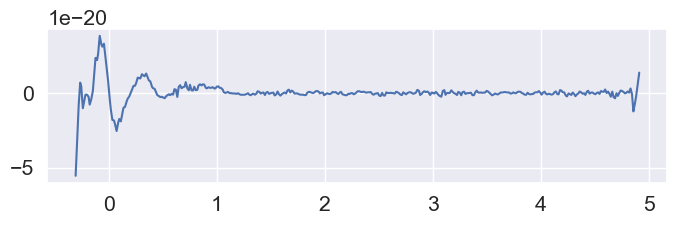

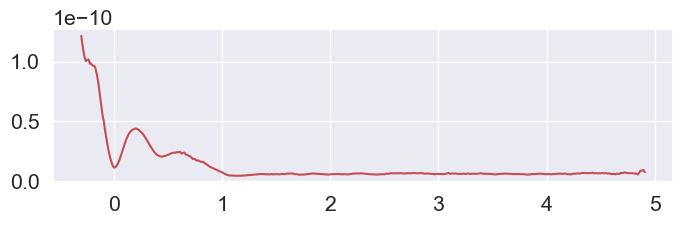

In [ ]:
avrg_measurement_0041_002_good = analysis.average_curves(measurements_0041_002_good)
visualization.plot_averaging(avrg_measurement_0041_002_good, measurements_0041_002_good, figsize=(8, 2))

force_0041_002_good = force.force_hoelscher(avrg_measurement_0041_002_good, calib_params_0041_002_good)
plt.figure(figsize=(8, 2))
plt.plot(*force_0041_002_good)
plt.show()

force_p_0041_002_good = force.force_payman(avrg_measurement_0041_002_good, calib_params_0041_002_good)
plt.figure(figsize=(8, 2))
plt.plot(*force_p_0041_002_good, 'r')
plt.show()

### Analyze statistics of measurements

In [ ]:
avrg_m = analysis.average_curves(measurements_0041_002, n_bins=1000)
force_0024_001 = force.force_hoelscher(avrg_m, calib_params_0041_002)

Average curves for direction='out': 100%|██████████| 1533/1533 [00:06<00:00, 236.22it/s]


100%|██████████| 1533/1533 [00:04<00:00, 359.13it/s]


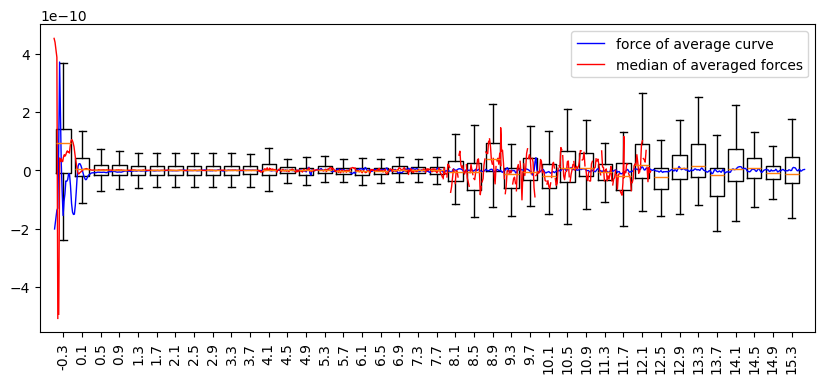

In [ ]:
ms = measurements_0041_002
calib_params = calib_params_0041_002
direction = 'out'

n_bins = 40
method = 'nanmedian'
cutoff = 800
avrg_z, avrg_force = force_0024_001

r_min = min([m[f'z_{direction}'][0] for m in ms])
r_max = max([m[f'z_{direction}'][:cutoff][-1] for m in ms])
box_width = (r_max - r_min) / (n_bins - 1) * 0.75

bins = np.linspace(r_min, r_max, n_bins + 1)
bins[-1] += 0.01
x_pos = ((bins[:-1] + bins[1:]) / 2)

forces = np.array([[a[:cutoff] for a in force.force_hoelscher(m, calib_params)] for m in ms])
f_bins = [np.split(f, np.cumsum(np.histogram(s, bins=bins)[0])[:-1]) for s, f in forces]
f_bins = list(map(list, zip(*f_bins)))
f_bins = [np.concatenate(f) for f in f_bins]

plt.figure(figsize=(10, 4))
plt.boxplot(f_bins, positions=x_pos, showfliers=False, widths=box_width)
plt.plot(avrg_z[:cutoff], avrg_force[:cutoff], label='force of average curve', color='b', linewidth=1)
plt.xticks(x_pos, x_pos.round(1), rotation=90)
plt.legend()
plt.show()

In [ ]:
zscore = 2
avrg_m_zs = analysis.average_curves(measurements_0041_002, n_bins=100, zscore_cutoff=zscore)
force_0024_001_zs = force.force_hoelscher(avrg_m, calib_params_0041_002)

Average curves for direction='out': 100%|██████████| 1533/1533 [00:00<00:00, 2122.54it/s]


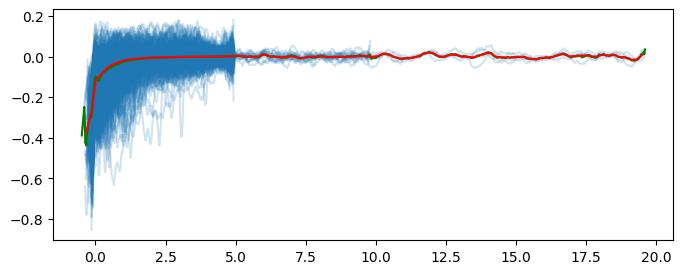

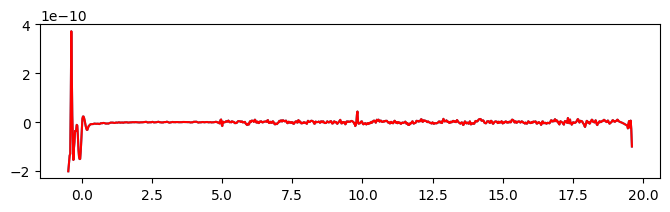

In [ ]:
signal_type = 'amp'
r = slice(None)
plt.figure(figsize=(8, 3))
for m in measurements_0041_002:
    plt.plot(m[f'z_{direction}'][r], m[f'{signal_type}_{direction}'][r], color='tab:blue', alpha=0.2)
plt.plot(avrg_m[f'z_{direction}'][r], avrg_m[f'{signal_type}_{direction}'][r], color='g')
plt.plot(avrg_m_zs[f'z_{direction}'][r], avrg_m_zs[f'{signal_type}_{direction}'][r], color='r')
plt.show()

plt.figure(figsize=(8, 2))
plt.plot(*force_0024_001)
plt.plot(*force_0024_001_zs, color='r')
plt.show()

### Compare average curves with different amount of preselection

Average curves for direction='out': 100%|██████████| 1533/1533 [00:07<00:00, 218.09it/s]


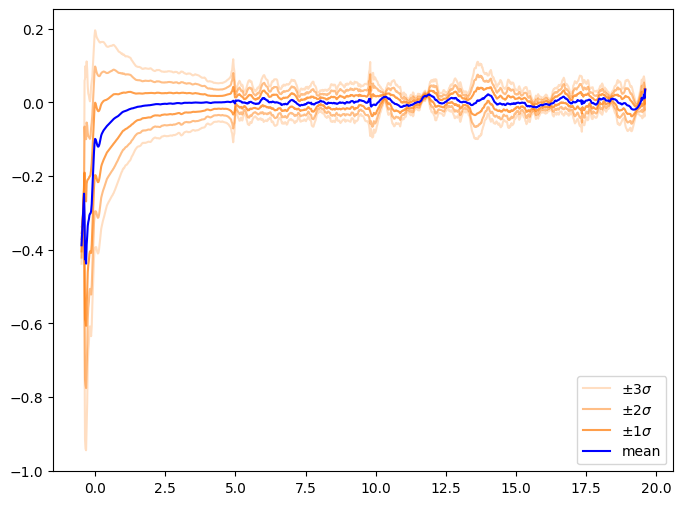

In [ ]:
zscores = [1, 2, 3]
zscores = np.concatenate([zscores, np.array(zscores) * -1]).tolist()
avrg_m, zscore_ms = analysis.average_curves(measurements_0041_002, n_bins=1000, zscores=zscores)
visualization.plot_average_with_uncertainty(avrg_m, zscore_ms, zscores=zscores, direction='out', signal_type='amp')

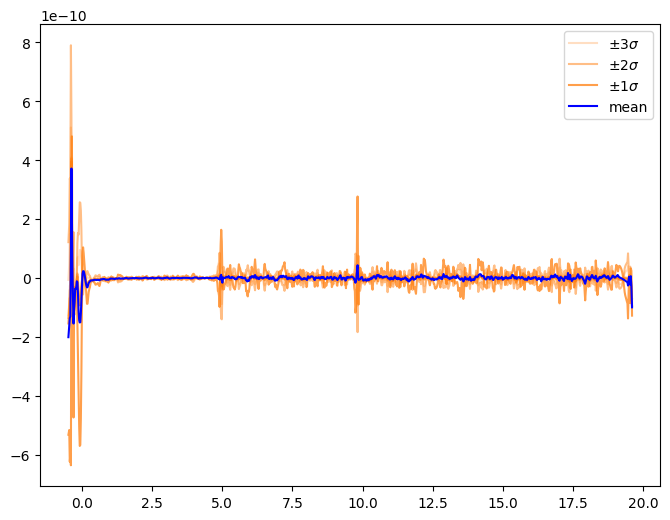

In [ ]:
force_0024_001 = force.force_hoelscher(avrg_m, calib_params_0041_002)
forces_zs = [force.force_hoelscher(m, calib_params_0041_002) for m in zscore_ms]
visualization.plot_force_with_uncertainty(force_0024_001, forces_zs, zscores=zscores)

Average curves for direction='out': 100%|██████████| 1226/1226 [00:05<00:00, 209.21it/s]


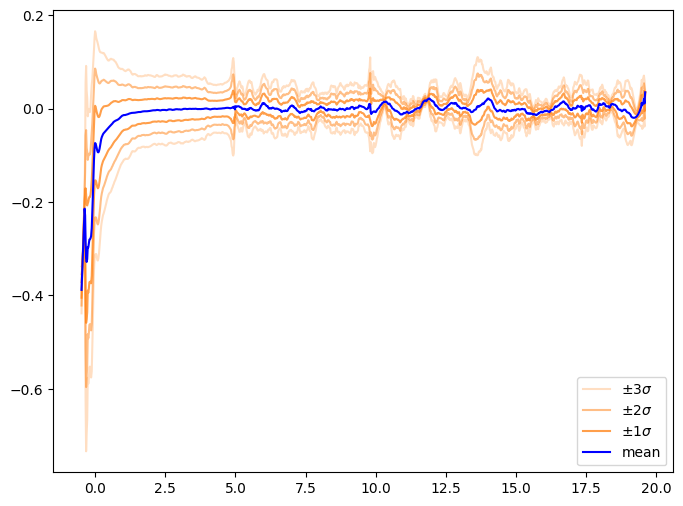

In [ ]:
ideal = 410
curve_type = 'amp_out'
p_choose = 0.8
n_choose = int(len(measurements_0041_002) * p_choose)
sorted_measurements, distances, sort_idcs = selection.sort_curves_by_distance(measurements_0041_002, ideal, curve_type)
selected_measurements = sorted_measurements[:n_choose]

avrg_m, zscore_ms = analysis.average_curves(selected_measurements, n_bins=1000, zscores=zscores)
visualization.plot_average_with_uncertainty(avrg_m, zscore_ms, zscores=zscores, direction='out', signal_type='amp')

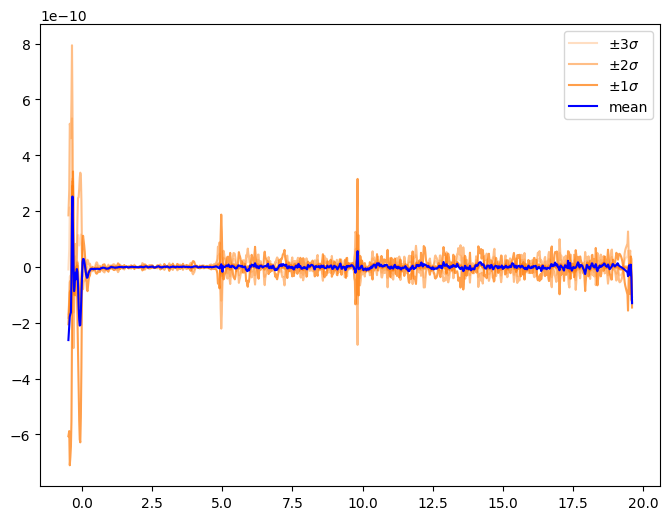

In [ ]:
force_0024_001 = force.force_hoelscher(avrg_m, calib_params_0041_002)
forces_zs = [force.force_hoelscher(m, calib_params_0041_002) for m in zscore_ms]
visualization.plot_force_with_uncertainty(force_0024_001, forces_zs, zscores=zscores)

Average curves for direction='out': 100%|██████████| 766/766 [00:03<00:00, 214.89it/s]


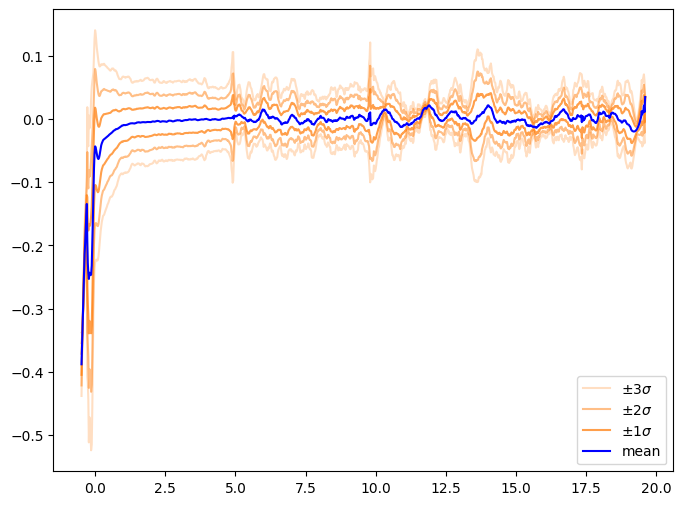

In [ ]:
p_choose = 0.5
n_choose = int(len(measurements_0041_002) * p_choose)
sorted_measurements, distances, sort_idcs = selection.sort_curves_by_distance(measurements_0041_002, ideal, curve_type)
selected_measurements = sorted_measurements[:n_choose]

avrg_m, zscore_ms = analysis.average_curves(selected_measurements, n_bins=1000, zscores=zscores)
visualization.plot_average_with_uncertainty(avrg_m, zscore_ms, zscores=zscores, direction='out', signal_type='amp')

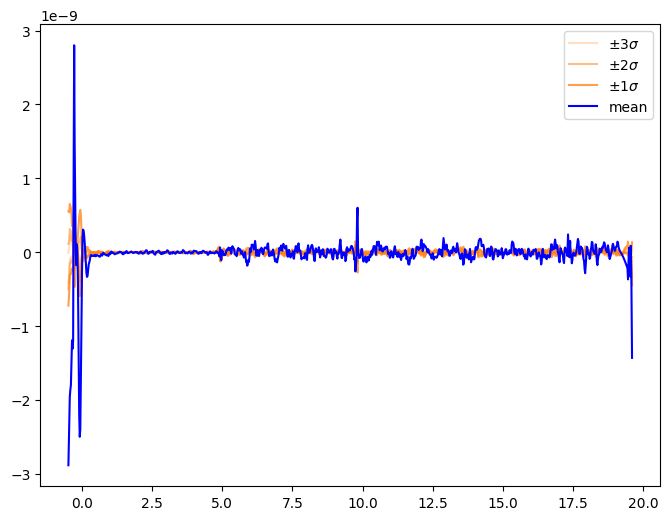

In [ ]:
force_0024_001 = force.force_hoelscher(avrg_m, calib_params_0041_002)
forces_zs = [force.force_hoelscher(m, calib_params_0041_002) for m in zscore_ms]
visualization.plot_force_with_uncertainty(force_0024_001, forces_zs, zscores=zscores)

Average curves for direction='out': 100%|██████████| 200/200 [00:01<00:00, 197.03it/s]


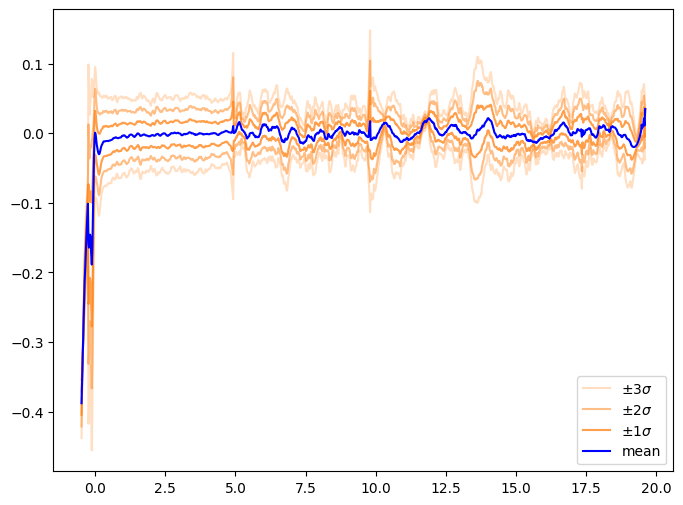

In [ ]:
n_choose = 200
sorted_measurements, distances, sort_idcs = selection.sort_curves_by_distance(measurements_0041_002, ideal, curve_type)
selected_measurements = sorted_measurements[:n_choose]

avrg_m, zscore_ms = analysis.average_curves(selected_measurements, n_bins=1000, zscores=zscores)
visualization.plot_average_with_uncertainty(avrg_m, zscore_ms, zscores=zscores, direction='out', signal_type='amp')

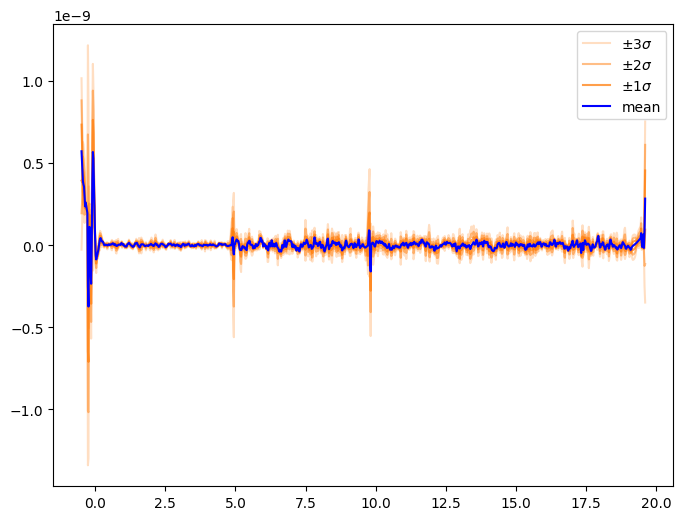

In [ ]:
force_0024_001 = force.force_hoelscher(avrg_m, calib_params_0041_002)
forces_zs = [force.force_hoelscher(m, calib_params_0041_002) for m in zscore_ms]
visualization.plot_force_with_uncertainty(force_0024_001, forces_zs, zscores=zscores)

# ---